# SpecFit: reproducible developer workflow

Synthetic two-region data exercise the real grid interpolation, broadening, RV, continuum marginalization and NumPyro paths. No sibling checkout, raw library or private data is required. This is a short plumbing demonstration, **not a convergence study**. Priors/initial values below are explicit example choices, never SpecFit defaults.

Run in a checkout with `jaxstar[spectral-inference]` and a Jupyter kernel. For CPU/GPU select `JAX_PLATFORMS=cpu`/`cuda` before starting the kernel; this notebook does not force a backend. Figures and short numeric summaries are retained; no posterior arrays are serialized.

In [1]:
from pathlib import Path
from dataclasses import replace
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src/jaxstar/specfit/fit.py').is_file())
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'dev_notebooks/specfit'))
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpyro.infer import init_to_value
from jaxstar.specfit import Observation, SpecModel, SpecFit
from _spectral_inference_data import synthetic_case
jax.config.update('jax_enable_x64', True)  # caller's precision choice
%matplotlib inline
print('Backend:', jax.default_backend(), 'JAX:', jax.__version__)

Backend: cpu JAX: 0.6.2


## Observation + physical model + orchestrator
The repository-only fixture constructs a prepared log-uniform library, `SpecModel` and `Observation`. Fixed masked flux/error deliberately contain NaN/Inf. Inject two spikes to make fit-mask replacement visible. Keep the small inference problem to Teff, vsini and RV; other physical/noise values are fixed explicitly. Atmosphere names still come from the library.

In [2]:
case = synthetic_case(regions=2, pixels=128, model_pixels=601)
flux = np.asarray(case.observation.flux).copy()
flux[0, 35] += .12
flux[1, 84] -= .10
obs = replace(case.observation, flux=flux)
specmodel = case.specmodel
assert isinstance(obs, Observation) and isinstance(specmodel, SpecModel)
fit = SpecFit(obs, specmodel, orders=('synthetic-0', 'synthetic-1'))
fixed_mask_before = np.asarray(obs.mask).copy()
config = {**case.priors,
    'atmosphere': {name: prior if name == 'teff' else case.truth[name]
                   for name, prior in case.priors['atmosphere'].items()},
    'broadening': {**case.priors['broadening'], 'vmacro': case.truth['vmacro']},
    'resolving_power': case.truth['resolving_power'],
    'sigma_continuum': .04, 'jitter': case.truth['jitter']}
initial = {name: case.initial[name] for name in ('teff', 'vsini', 'rv')}
print('Observation:', obs.shape, 'model grid:', specmodel.spectra.wavelength.shape)
print('Fixed masked:', np.sum(obs.mask), 'fit masked:', np.sum(fit.fit_mask))

Observation: (2, 128) model grid: (2, 601)
Fixed masked: 14 fit masked: 0


## CCF initialization
Pass explicit template atmosphere coordinates. The legacy CCF is unweighted and median-combined over regions; its width is a diagnostic and never automatically becomes a prior. This synthetic library has repeated line spacings, so inspect its CCF rather than treating its width as a calibrated rotation estimate.

Injected RV: 12.400; CCF RV: 12.587; width: 45.410 km/s
Region RVs: [12.47572454 12.69850533]


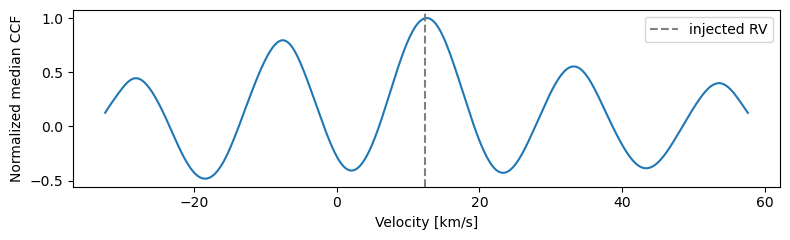

In [3]:
template = {name: case.truth[name] for name in specmodel.spectra.grid.axis_names}
ccf_rv, ccf_width = fit.check_ccf(template, v_limit=35., ccfvmax=45.)
print(f'Injected RV: {case.truth["rv"]:.3f}; CCF RV: {ccf_rv:.3f}; width: {ccf_width:.3f} km/s')
print('Region RVs:', fit.ccf['region_rv'])
initial['rv'] = float(np.clip(ccf_rv, 8.01, 16.99))  # explicit caller choice
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(fit.ccf['velocity'], fit.ccf['combined'] / fit.ccf['combined'].max())
ax.axvline(case.truth['rv'], color='gray', ls='--', label='injected RV')
ax.set(xlabel='Velocity [km/s]', ylabel='Normalized median CCF')
ax.legend(); fig.tight_layout(); plt.show()

## SVI point and initial reconstruction
`run_svi` returns the existing inferutils guide-median dict. Reconstruction replays the same external NumPyro model at that one point, then calls existing continuum/GP helpers. No fitted arrays are stored in individual posterior draws.

Initial SVI: {'teff': 5962.108, 'vsini': 7.533, 'rv': 12.5261}
Initial residual diagnostics: [{'region': 'synthetic-0', 'n_usable': 121, 'rms': 0.011995409972919436, 'mad_scale': 0.005608397088280174, 'standardized_rms': 2.120508933741019, 'n_gt_3sigma': 1, 'n_gt_5sigma': 1, 'n_adjacent_pairs': 118, 'lag1_correlation': 0.04247850497862727}, {'region': 'synthetic-1', 'n_usable': 121, 'rms': 0.01039489229733218, 'mad_scale': 0.005385908848676019, 'standardized_rms': 1.837574708286849, 'n_gt_3sigma': 2, 'n_gt_5sigma': 1, 'n_adjacent_pairs': 118, 'lag1_correlation': 0.004153198018184342}]


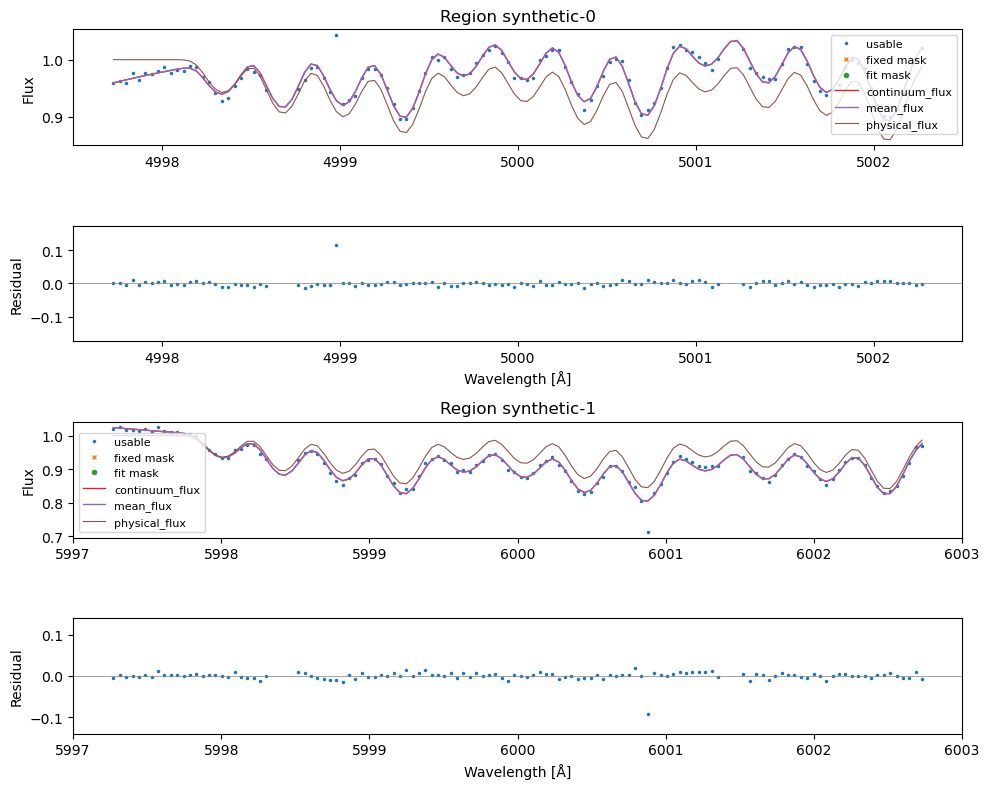

In [4]:
point = fit.run_svi(rng_key=jax.random.PRNGKey(0), model_kwargs=config,
    step_size=.03, num_steps=250, p_initial=initial, progress_bar=False)
pred = fit.reconstruct(point, model_kwargs=config)
print('Initial SVI:', {name: round(float(point[name]), 4) for name in initial})
print('Initial residual diagnostics:', fit.residual_diagnostics(pred['mean_flux'], jitter=pred['jitter']))
fig, axes = fit.plot_models(pred, show_physical=True)
plt.show()

## Replace the outlier mask, then refit
The default clipping baseline is **physical × conditional continuum**, `continuum_flux`. It excludes the GP mean even in GP mode. The median-filter/MAD rule recomputes from the fixed-mask usable data, replacing old flags. Run extension is enabled here. `set_fit_mask` and `reset_fit_mask` provide direct control.

In [5]:
fit.mask_outliers(pred, sigma_threshold=5.)
print('Fit-mask pixel indices:', [np.flatnonzero(row).tolist() for row in fit.fit_mask])
assert fit.fit_mask[0, 35] and fit.fit_mask[1, 84]
np.testing.assert_array_equal(obs.mask, fixed_mask_before)
point = fit.run_svi(rng_key=jax.random.PRNGKey(1), model_kwargs=config,
    step_size=.02, num_steps=150, p_initial=point, progress_bar=False)
pred = fit.reconstruct(point, model_kwargs=config)
print('Refit SVI:', {name: round(float(point[name]), 4) for name in initial})
print('Usable after refit:', np.sum(~fit.fit_observation().mask))

Fit-mask pixel indices: [[34, 35, 36], [83, 84, 85]]


Refit SVI: {'teff': 5796.4549, 'vsini': 7.5244, 'rv': 12.4368}
Usable after refit: 236


## Short ordinary NUTS and explicit posterior point
A single short chain checks orchestration, not mixing or scientific uncertainty. Inspect the summary/divergences before extending this run for an actual application. The returned `MCMC` object and all ordinary NumPyro APIs remain available.

,parameter,truth,median,p05,p95
0,teff,5770.0,5790.075623,5751.733619,5836.725460
1,vsini,7.5,7.503316,7.419816,7.620991
2,rv,12.4,12.432382,12.364138,12.513623


Draws: 60 divergences: 0


,region,n_usable,rms,mad_scale,standardized_rms,n_gt_3sigma,n_gt_5sigma,n_adjacent_pairs,lag1_correlation
0,synthetic-0,118,0.005303,0.005386,0.937535,0,0,114,0.087327
1,synthetic-1,118,0.005206,0.005227,0.920357,0,0,114,-0.090758


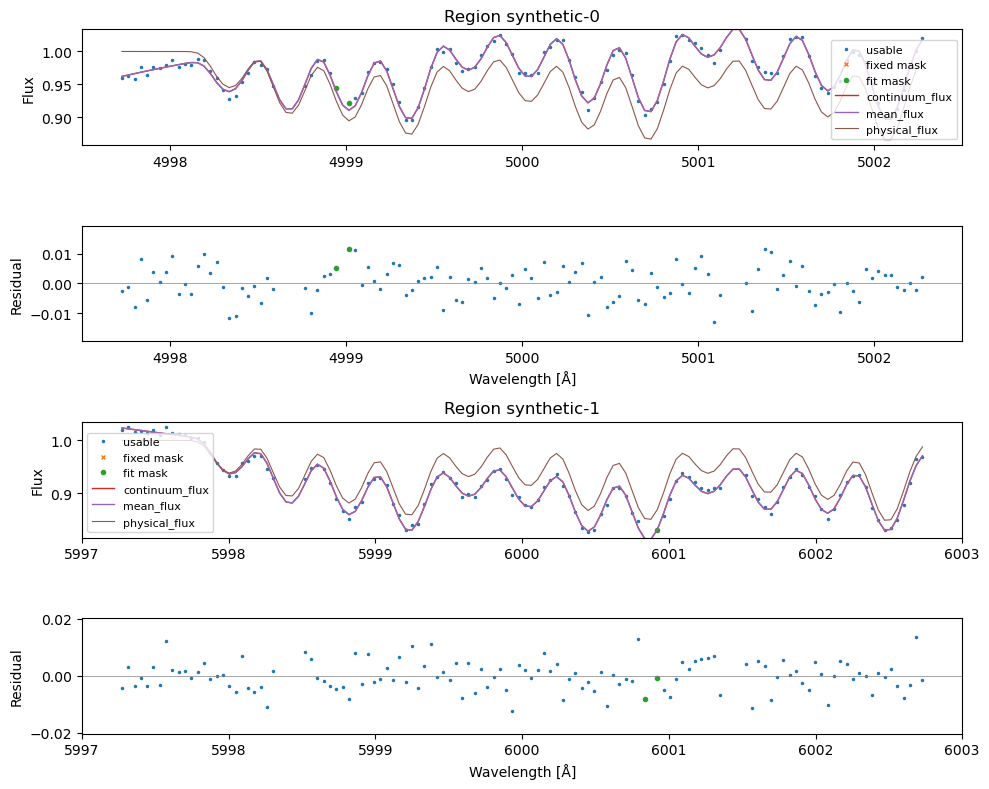

In [6]:
mcmc = fit.run_nuts(rng_key=jax.random.PRNGKey(2), model_kwargs=config,
    num_warmup=50, num_samples=60, progress_bar=False,
    nuts_kwargs={'init_strategy': init_to_value(values=point), 'dense_mass': True,
                 'max_tree_depth': 5})
samples = mcmc.get_samples()
summary = pd.DataFrame([{'parameter': name, 'truth': case.truth[name],
    'median': float(np.median(samples[name])),
    'p05': float(np.quantile(samples[name], .05)),
    'p95': float(np.quantile(samples[name], .95))} for name in initial])
display(summary)
print('Draws:', len(samples['rv']), 'divergences:', int(np.sum(mcmc.get_extra_fields()['diverging'])))
posterior_point = {name: np.median(value, axis=0) for name, value in samples.items()}
final = fit.reconstruct(posterior_point, model_kwargs=config)
display(pd.DataFrame(fit.residual_diagnostics(final['mean_flux'], jitter=final['jitter'])))
fig, axes = fit.plot_models(final, show_physical=True)
plt.show()

## Optional small GP path
Same observation/model/mask and external callable. Here amplitude/scale are fixed example values, not inferred GP priors. A few GP SVI/NUTS steps check the ordinary fixed-mask route. Final residual diagnostics use `mean_flux`; outlier clipping would still default to `continuum_flux`. To opt in to GP-mean clipping explicitly use `fit.mask_outliers(prediction=gp_pred['mean_flux'], mask_v=...)`. No GP benchmark or long real-data fit is rerun.

In [7]:
RUN_GP = True
if RUN_GP:
    gp_config = {**config, 'gp_amplitude': .006, 'gp_scale': .12}
    gp_point = fit.run_svi(rng_key=jax.random.PRNGKey(3), model_kwargs=gp_config,
        step_size=.01, num_steps=40, p_initial=point, progress_bar=False)
    gp_mcmc = fit.run_nuts(rng_key=jax.random.PRNGKey(4), model_kwargs=gp_config,
        num_warmup=10, num_samples=10, progress_bar=False,
        nuts_kwargs={'init_strategy': init_to_value(values=gp_point), 'max_tree_depth': 3})
    gp_samples = gp_mcmc.get_samples()
    gp_point = {name: np.median(value, axis=0) for name, value in gp_samples.items()}
    gp_pred = fit.reconstruct(gp_point, model_kwargs=gp_config)
    print('GP smoke draws:', len(gp_samples['rv']), 'finite mean:', bool(np.isfinite(gp_pred['mean_flux']).all()))
    display(pd.DataFrame(fit.residual_diagnostics(gp_pred['mean_flux'], jitter=gp_pred['jitter'])))
    print('Max |GP mean|:', float(np.max(np.abs(gp_pred['gp_mean']))))
np.testing.assert_array_equal(obs.mask, fixed_mask_before)

GP smoke draws: 10 finite mean: True


,region,n_usable,rms,mad_scale,standardized_rms,n_gt_3sigma,n_gt_5sigma,n_adjacent_pairs,lag1_correlation
0,synthetic-0,118,0.004137,0.004620,0.731256,0,0,114,-0.294808
1,synthetic-1,118,0.004120,0.003908,0.728336,0,0,114,-0.484650


Max |GP mean|: 0.006547478049390246


The separate `dev_notebooks/local/specfit/real_order8_inference.ipynb` remains local-only. Nothing here depends on it or on frozen jaxspec. SpecFit does not choose priors, load spectra or replace direct model/NumPyro usage. For a real application, lengthen inference and evaluate convergence and the physical adequacy of the library/noise model.